# GPT Model — Full Decoder Architecture

Continues from `base_model.ipynb` (tokenizer, dataset, basic attention).

## Components
1. Layer Normalization
2. GELU Activation
3. Feed-Forward Network
4. Shortcut Connections
5. Multi-Head Attention (efficient single-matrix)
6. Transformer Block
7. GPT Model
8. Weight Tying & Parameter Count
9. Text Generation

## Imports

In [1]:
import math
import torch
import torch.nn as nn
import tiktoken
import matplotlib.pyplot as plt
from importlib.metadata import version

print(f"torch version:    {version('torch')}")
print(f"tiktoken version: {version('tiktoken')}")
print(f"CUDA available:   {torch.cuda.is_available()}")

torch version:    2.9.0
tiktoken version: 0.9.0
CUDA available:   True


## Config

In [2]:
GPT_CONFIG_124M = {
    "vocab_size":       50257,
    "context_length":   1024,
    "emb_dim":          768,
    "n_heads":          12,
    "n_layers":         12,
    "drop_rate":        0.1,
    "qkv_bias":         False,
}

## 1 — Layer Normalization

Normalises each token's embedding vector to zero mean, unit variance, then applies
learnable per-dimension `scale` and `shift` parameters.
Unlike BatchNorm, statistics are computed **per sample** (over the embedding dimension),
so behaviour is identical at training and inference time.

In [3]:
torch.manual_seed(123)
batch_example = torch.randn(2, 5)
layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)

mean = out.mean(dim=-1, keepdim=True)
var  = out.var(dim=-1,  keepdim=True)
out_norm = (out - mean) / torch.sqrt(var)

mean_n = out_norm.mean(dim=-1, keepdim=True)
var_n  = out_norm.var(dim=-1,  keepdim=True)
torch.set_printoptions(sci_mode=False)
print(f"Normalised output:\n{out_norm}")
print(f"Mean after norm: {mean_n}")
print(f"Var  after norm: {var_n}")

Normalised output:
tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean after norm: tensor([[0.0000],
        [0.0000]], grad_fn=<MeanBackward1>)
Var  after norm: tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [4]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps   = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean   = x.mean(dim=-1, keepdim=True)
        var    = x.var(dim=-1,  keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift


# Smoke test
ln      = LayerNorm(emb_dim=5)
out_ln  = ln(batch_example)
mean_ln = out_ln.mean(dim=-1, keepdim=True)
var_ln  = out_ln.var(dim=-1,  keepdim=True, unbiased=False)
print(f"Mean: {mean_ln}")
print(f"Var:  {var_ln}")

Mean: tensor([[-0.0000],
        [ 0.0000]], grad_fn=<MeanBackward1>)
Var:  tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


## 2 — GELU Activation

GELU (Gaussian Error Linear Unit) is a smooth approximation to ReLU used in GPT-2.
Unlike ReLU it has a non-zero gradient for small negative inputs, which helps gradient
flow in deep networks.

$$\text{GELU}(x) = 0.5 \cdot x \cdot \left(1 + \tanh\!\left(\sqrt{\tfrac{2}{\pi}}\,(x + 0.044715\,x^3)\right)\right)$$

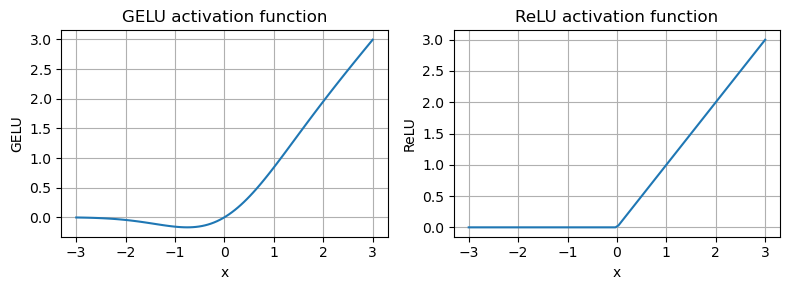

In [5]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return (
            0.5 * x *
            (1 + torch.tanh(
                torch.sqrt(torch.tensor(2.0 / torch.pi)) *
                (x + 0.044715 * torch.pow(x, 3))
            ))
        )


gelu, relu = GELU(), nn.ReLU()
x = torch.linspace(-3, 3, 100)

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([gelu(x), relu(x)], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x.numpy(), y.detach().numpy())
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(label)
    plt.grid(True)
plt.tight_layout()
plt.show()

## 3 — Feed-Forward Network

Two-layer MLP applied independently to each token position.
The hidden layer expands to **4 × emb_dim** then projects back, giving the model
capacity to store factual associations between token representations.

In [6]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)


# Smoke test
ffn = FeedForward(GPT_CONFIG_124M)
x   = torch.rand(2, 3, 768)
print(f"FFN input shape:  {x.shape}")
print(f"FFN output shape: {ffn(x).shape}")

FFN input shape:  torch.Size([2, 3, 768])
FFN output shape: torch.Size([2, 3, 768])


## 4 — Shortcut Connections

Residual (skip) connections add the block's input directly to its output.
Without them, gradients vanish exponentially as they backpropagate through many layers.
The plot below shows that **with** shortcuts the gradient magnitudes stay roughly
constant across all layers, while **without** them they shrink to near-zero in early layers.

In [7]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut=False):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[i], layer_sizes[i + 1]), GELU())
            for i in range(len(layer_sizes) - 1)
        ])

    def forward(self, x):
        for layer in self.layers:
            out = layer(x)
            if self.use_shortcut and x.shape == out.shape:
                x = x + out
            else:
                x = out
        return x


def print_gradients(model, x):
    output = model(x)
    loss   = nn.MSELoss()(output, torch.zeros_like(output))
    loss.backward()
    for name, param in model.named_parameters():
        if "weight" in name:
            print(f"{name:35s}  grad mean = {param.grad.abs().mean().item():.6f}")


layer_sizes  = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])

print("--- Without shortcut connections ---")
torch.manual_seed(123)
print_gradients(ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=False), sample_input)

print("\n--- With shortcut connections ---")
torch.manual_seed(123)
print_gradients(ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=True), sample_input)

--- Without shortcut connections ---
layers.0.0.weight                    grad mean = 0.000202
layers.1.0.weight                    grad mean = 0.000120
layers.2.0.weight                    grad mean = 0.000715
layers.3.0.weight                    grad mean = 0.001399
layers.4.0.weight                    grad mean = 0.005050

--- With shortcut connections ---
layers.0.0.weight                    grad mean = 0.221698
layers.1.0.weight                    grad mean = 0.206941
layers.2.0.weight                    grad mean = 0.328970
layers.3.0.weight                    grad mean = 0.266573
layers.4.0.weight                    grad mean = 1.325854


## 5 — Multi-Head Attention (efficient)

Replaces the naive `MultiHeadAttentionWrapper` (one full QKV matrix per head) with a
**single** set of projection matrices split across heads via `.view()` + `.transpose()`.
This avoids `num_heads` separate forward passes and is the standard production approach.

Key shapes through the forward pass:
```
Q/K/V after projection : [batch, num_tokens, d_out]
After split to heads    : [batch, num_tokens, num_heads, head_dim]
After transpose         : [batch, num_heads, num_tokens, head_dim]
Context vector          : [batch, num_tokens, d_out]   (after transpose + view)
```

In [8]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"
        self.d_out    = d_out
        self.num_heads = num_heads
        self.head_dim  = d_out // num_heads
        self.W_query  = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key    = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value  = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout  = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        keys    = self.W_key(x)
        queries = self.W_query(x)
        values  = self.W_value(x)

        # Split d_out into (num_heads, head_dim)
        keys    = keys.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values  = values.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

        attn_scores = queries @ keys.transpose(2, 3)
        attn_scores.masked_fill_(self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)
        attn_weights = torch.softmax(attn_scores / self.head_dim ** 0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # [batch, num_heads, num_tokens, head_dim] -> [batch, num_tokens, d_out]
        context_vec = (attn_weights @ values).transpose(1, 2).contiguous()
        context_vec = context_vec.view(b, num_tokens, self.d_out)
        return self.out_proj(context_vec)


# Smoke test
tokenizer = tiktoken.get_encoding("gpt2")
batch = torch.stack([
    torch.tensor(tokenizer.encode("Every effort moves you")),
    torch.tensor(tokenizer.encode("Every day hold a")),
])

torch.manual_seed(123)
mha = MultiHeadAttention(
    d_in=GPT_CONFIG_124M["emb_dim"],
    d_out=GPT_CONFIG_124M["emb_dim"],
    context_length=GPT_CONFIG_124M["context_length"],
    dropout=GPT_CONFIG_124M["drop_rate"],
    num_heads=GPT_CONFIG_124M["n_heads"],
)
# Use a small embedding for shape demo
emb  = nn.Embedding(GPT_CONFIG_124M["vocab_size"], GPT_CONFIG_124M["emb_dim"])
x_in = emb(batch)
print(f"MHA input:  {x_in.shape}")
print(f"MHA output: {mha(x_in).shape}")

MHA input:  torch.Size([2, 4, 768])
MHA output: torch.Size([2, 4, 768])


## 6 — Transformer Block

Combines MHA + FFN with pre-LayerNorm and residual connections:

```
x → LayerNorm → MHA    → dropout → + x  →  (shortcut 1)
x → LayerNorm → FFN    → dropout → + x  →  (shortcut 2)
```

Pre-norm (norm before the sublayer) is more stable than the original post-norm
Transformer and is used in GPT-2.

In [9]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"],
        )
        self.ff           = FeedForward(cfg)
        self.norm1        = LayerNorm(cfg["emb_dim"])
        self.norm2        = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Attention sub-layer
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        # FFN sub-layer
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        return x


# Smoke test
torch.manual_seed(123)
x     = torch.rand(2, 4, GPT_CONFIG_124M["emb_dim"])
block = TransformerBlock(GPT_CONFIG_124M)
out   = block(x)
print(f"TransformerBlock input shape:  {x.shape}")
print(f"TransformerBlock output shape: {out.shape}")

TransformerBlock input shape:  torch.Size([2, 4, 768])
TransformerBlock output shape: torch.Size([2, 4, 768])


## 7 — GPT Model

Assembles the full decoder:
```
token_ids → tok_emb + pos_emb → dropout
          → N × TransformerBlock
          → LayerNorm
          → Linear(emb_dim → vocab_size)   [LM head]
```

In [10]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb    = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb    = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb   = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head   = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = self.drop_emb(tok_embeds + pos_embeds)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        return self.out_head(x)


# Smoke test
torch.manual_seed(123)
model  = GPTModel(GPT_CONFIG_124M)
logits = model(batch)
print(f"Input shape:  {batch.shape}     [batch, seq_len]")
print(f"Output shape: {logits.shape}    [batch, seq_len, vocab_size]")

Input shape:  torch.Size([2, 4])     [batch, seq_len]
Output shape: torch.Size([2, 4, 50257])    [batch, seq_len, vocab_size]


## 8 — Weight Tying & Parameter Count

GPT-2 **ties** the token embedding matrix to the output projection (LM head),
so they share weights. This reduces parameters by ~38M and improves generalisation.

We keep them separate here to match the training setup in `GPTModel.ipynb` from
llm-from-scratch, but note the option below.

In [11]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters:                    {total_params:,}")

# Subtract out_head to simulate weight tying
params_with_tying = total_params - sum(p.numel() for p in model.out_head.parameters())
print(f"Parameters with weight tying:        {params_with_tying:,}")

total_size_mb = total_params * 4 / (1024 ** 2)
print(f"Model size (float32):                {total_size_mb:.1f} MB")

print(f"\ntok_emb weight shape:  {model.tok_emb.weight.shape}")
print(f"out_head weight shape: {model.out_head.weight.shape}")

Total parameters:                    163,009,536
Parameters with weight tying:        124,412,160
Model size (float32):                621.8 MB

tok_emb weight shape:  torch.Size([50257, 768])
out_head weight shape: torch.Size([50257, 768])


## 9 — Text Generation

`generate_text_simple` uses **greedy decoding** (argmax at each step).
It always picks the single most likely next token — fast and deterministic,
but produces repetitive text. Temperature sampling and top-k / top-p filtering
come later in the training pipeline.

In [12]:
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    return torch.tensor(encoded).unsqueeze(0)   # [1, seq_len]


def token_ids_to_text(token_ids, tokenizer):
    return tokenizer.decode(token_ids.squeeze(0).tolist())


def generate_text_simple(model, idx, max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        idx_next = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1)
    return idx


# Smoke test (random weights — output is gibberish)
model.eval()
start_context = "Every effort moves you"
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"],
)
print(f"Generated: {token_ids_to_text(token_ids, tokenizer)!r}")

Generated: 'Every effort moves you Aeiman Byeswickattributeometer inspector Normandy freezerigrate'


## Checklist Summary

| Component            | Class / Function          | Status |
|----------------------|---------------------------|--------|
| Layer Normalization  | `LayerNorm`               | ✓ |
| GELU activation      | `GELU`                    | ✓ |
| Feed-Forward Network | `FeedForward`             | ✓ |
| Shortcut connections | residuals in `TransformerBlock` | ✓ |
| Multi-Head Attention | `MultiHeadAttention`      | ✓ |
| Transformer Block    | `TransformerBlock`        | ✓ |
| Full GPT Model       | `GPTModel`                | ✓ |
| Text generation      | `generate_text_simple`    | ✓ |
| Training loop        | —                         | → `train.ipynb` |
| LR scheduler         | —                         | → `train.ipynb` |
| Checkpointing        | —                         | → `train.ipynb` |
| Evaluation / PPL     | —                         | → `train.ipynb` |